In [1]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

In [22]:
# DIR = Path("../../artifacts/2023-06-s8/dev/accuracy-basis")
DIR = Path("../../artifacts/2023-06-s8/dev/accuracy")

In [23]:
def load(dataset, logit_mod, arch, layer, basis_name, basis_mode):
    with open(DIR / dataset / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
        data = json.load(fh)
        
    return data

load("cifar100-people--n50", "multipleclasses", "cifar100-resnet18-p1", "layer3", "pca", basis_mode="centered");

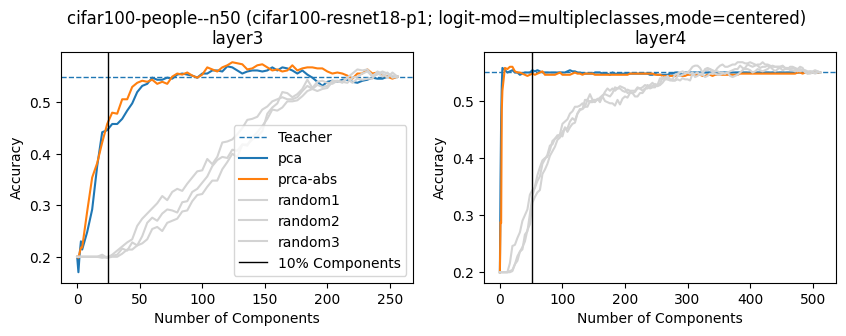

In [25]:
def color(name):
    if "random" in name:
        return "lightgray"
    else:
        return None
def viz(dataset, logit_mod, num_samples=50, basis_mode="centered"):
    dataset =  f"{dataset}--n{num_samples}"
    arch = "cifar100-resnet18-p1"
    layers = ["layer3", "layer4"]
    
    basis_names = [
        "pca", "prca-abs",
        "random1", "random2", "random3"
    ]
    
    ncols = len(layers)
    plt.figure(figsize=(ncols * 5, 3))
    plt.suptitle(f"{dataset} ({arch}; logit-mod={logit_mod},mode={basis_mode})", y=1.02)
    
    
    nn = None
    for lix, layer in enumerate(layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        plt.ylabel("Accuracy")
        plt.xlabel("Number of Components")
        for bix, basis_name in enumerate(basis_names):
            data = load(dataset, logit_mod, arch, layer, basis_name, basis_mode)
            

            if bix == 0:
                plt.axhline(data["original_auroc"], ls='--', lw=1, label="Teacher")
            
            plt.plot(
                data["arr_ks"][:nn], data["arr_acc"][:nn],
                label=basis_name, color=color(basis_name)
            )
            
            
        d = data["arr_ks"][-1] 
        plt.axvline(int(0.1*d), ls="-", lw=1, color="k", label="10% Components")
        
        if lix == 0:
            plt.legend()
        
viz("cifar100-people", "multipleclasses", basis_mode="centered")

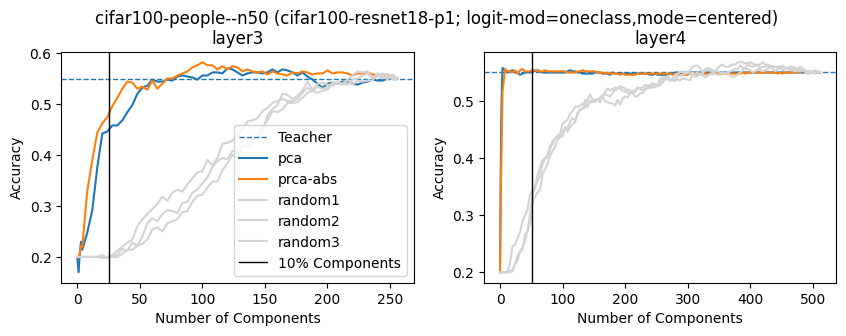

In [26]:
viz("cifar100-people", "oneclass")

In [27]:
# viz("cifar100-people", "oneclass", num_samples=500)

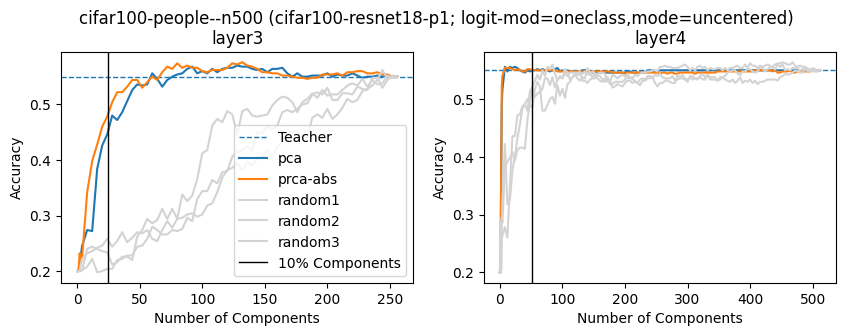

In [28]:
viz("cifar100-people", "oneclass", num_samples=500, basis_mode="uncentered")

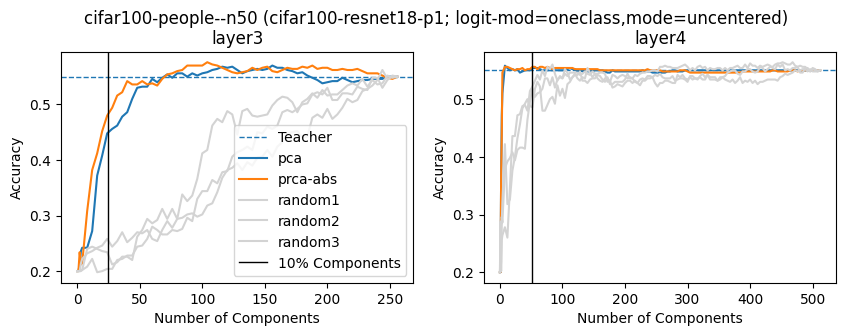

In [29]:
viz("cifar100-people", "oneclass", num_samples=50, basis_mode="uncentered")

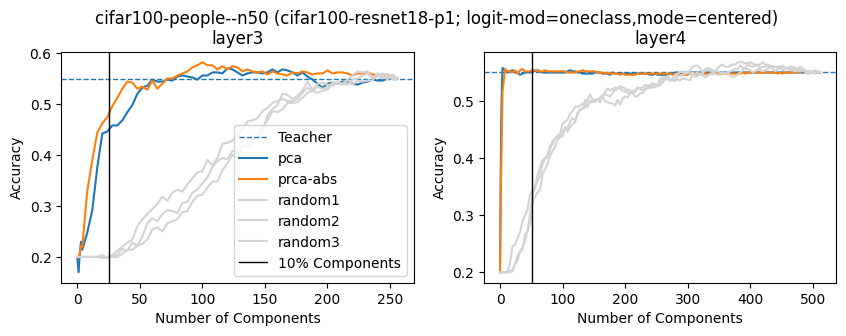

In [30]:
viz("cifar100-people", "oneclass", num_samples=50, basis_mode="centered")

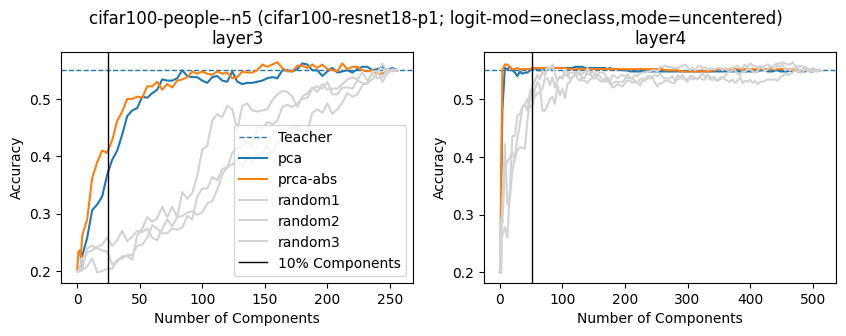

In [31]:
viz("cifar100-people", "oneclass", num_samples=5, basis_mode="uncentered")

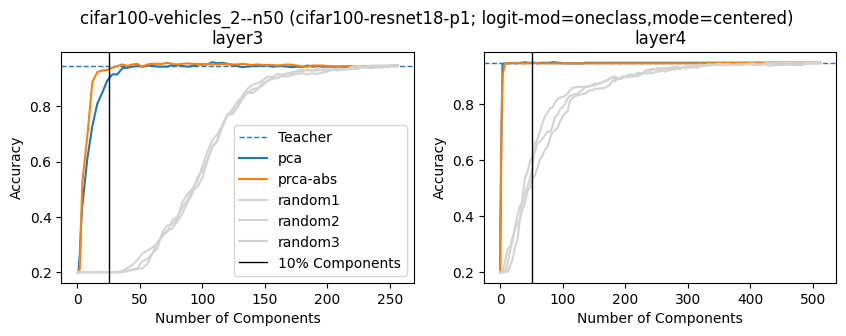

In [11]:
viz("cifar100-vehicles_2", "oneclass", num_samples=50, basis_mode="centered")

# Grid Accuracy

FileNotFoundError: [Errno 2] No such file or directory: '../../artifacts/2023-06-s8/dev/accuracy/cifar100-people/logit-mod-oneclass/cifar100-resnet18-p1/layer3/pca--centered/stats.json'

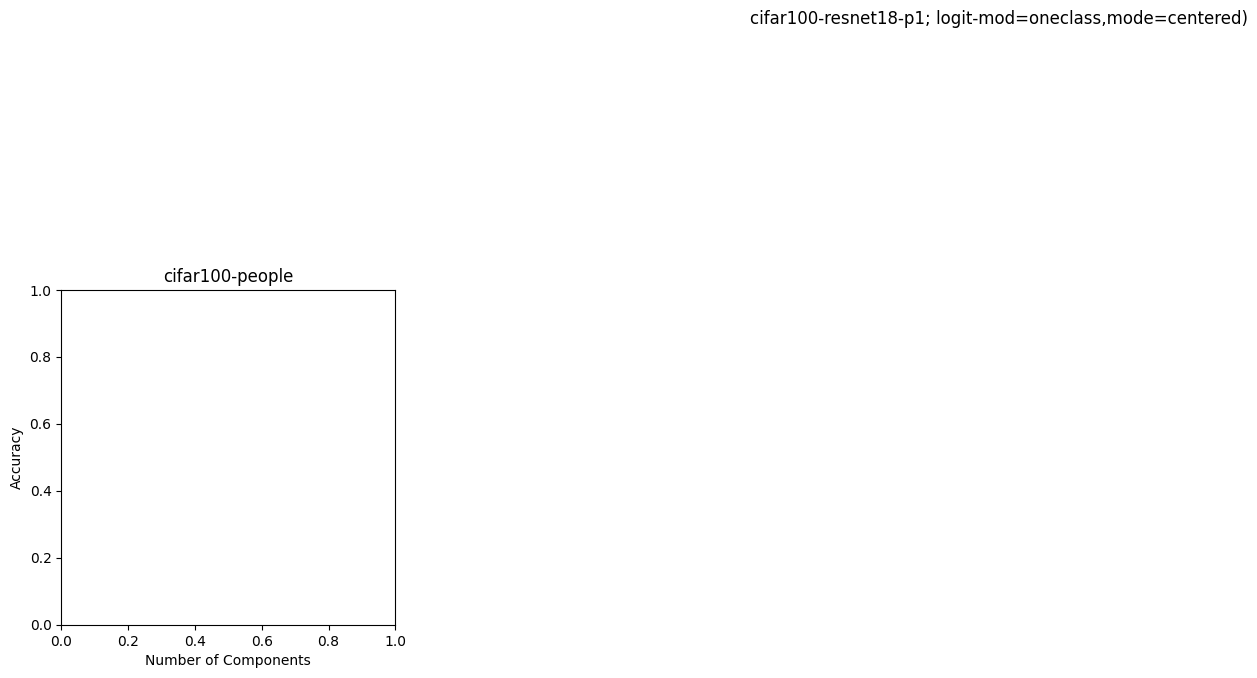

In [13]:
def grid():
    layer = "layer3"
    arch = "cifar100-resnet18-p1"
    num_samples = 50
    logit_mod = "oneclass"
    basis_mode = "centered"
    
    basis_names = [
        "pca", "prca-abs",
        "random1", "random2", "random3"
    ]
    
    
    
    
    datasets = ["cifar100-people"]
    
    
    ncols = 5
    nrows = 4
    
    plt.figure(
        figsize=(ncols * 5, nrows*5)
    )
    plt.suptitle(f"{arch}; logit-mod={logit_mod},mode={basis_mode})", y=1.02)
    
    for dix, dataset in enumerate(datasets):
        plt.subplot(nrows, ncols, dix + 1)
        plt.title(dataset)
        plt.ylabel("Accuracy")
        plt.xlabel("Number of Components")
        for bix, basis_name in enumerate(basis_names):
            data = load(dataset, logit_mod, arch, layer, basis_name, basis_mode)
            
            if bix == 0:
                plt.axhline(data["original_auroc"], ls='--', lw=1, label="Teacher")
            
            plt.plot(
                data["arr_ks"][:nn], data["arr_acc"][:nn],
                label=basis_name, color=color(basis_name)
            )
            
            
        d = data["arr_ks"][-1] 
        plt.axvline(int(0.1*d), ls="-", lw=1, color="k", label="10% Components")
        
        if lix == 0:
            plt.legend()
grid()